### New Soil FertilityStatus Notebook

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

pd.set_option('display.max_columns', None)

In [2]:
# Get the absolute path of the directory one level up (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# import SoilDataPreprocessor
from api.utils.preprocessing import SoilDataPreprocessor

### Loading the data

In [3]:
df = pd.read_excel("../data/Select_Counties_Soil_Health_2026.xlsx", index_col=0)
df.head(10)

,County,pH,Total N (%),TOC (%),P (ppm),K (me%),Ca (me%),Mg (me%),K (ppm),Ca (ppm),Mg (ppm),pH Score,pH Class,pH Interpretation,N Score,N Class,N Interpretation,OC Score,OC Class,OC Interpretation,P Score,P Class,P Interpretation,K Score,K Class,K Interpretation,Ca Score,Ca Class,Ca Interpretation,Mg Score,Mg Class,Mg Interpretation,SHI,Override Rule(s) Applied,Final Classification,Recommended Actions
Row #,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Baringo,3.81,0.24,2.63,20.0,0.70,0.4,1.22,273.0,80.0,146.4,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.42,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
2,Baringo,3.98,0.26,2.85,20.0,0.40,0.4,0.80,156.0,80.0,96.0,1,Very Poor,Extreme pH; nutrient lock-out,4,Healthy,Adequate nitrogen,3,Moderately Healthy,Adequate; build up recommended,3,Moderately Healthy,Moderate; may need supplementation,3,Moderately Healthy,Moderate; crop-dependent,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.46,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
3,Baringo,3.99,0.17,1.75,25.0,1.55,0.8,1.12,604.5,160.0,134.4,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,2,Poor,Low; add organic inputs,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.23,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
4,Baringo,4.12,0.40,4.25,10.0,0.32,0.4,2.55,124.8,80.0,306.0,1,Very Poor,Extreme pH; nutrient lock-out,4,Healthy,Adequate nitrogen,4,Healthy,Good organic matter,2,Poor,Deficient; P fertilizer needed,3,Moderately Healthy,Moderate; crop-dependent,1,Very Poor,Severely deficient in Ca,4,Healthy,Adequate magnesium,2.65,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
5,Baringo,4.15,0.24,2.63,15.0,0.80,0.4,1.05,312.0,80.0,126.0,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,2,Poor,Deficient; P fertilizer needed,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.27,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
6,Baringo,4.16,0.44,4.41,17.0,0.43,3.5,0.80,167.7,700.0,96.0,1,Very Poor,Extreme pH; nutrient lock-out,4,Healthy,Adequate nitrogen,4,Healthy,Good organic matter,2,Poor,Deficient; P fertilizer needed,4,Healthy,Adequate potassium,2,Poor,Low calcium; liming may help,2,Poor,Low Mg; supplement needed,2.69,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
7,Baringo,4.19,0.40,4.22,20.0,0.72,0.4,1.50,280.8,80.0,180.0,1,Very Poor,Extreme pH; nutrient lock-out,4,Healthy,Adequate nitrogen,4,Healthy,Good organic matter,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,3,Moderately Healthy,Moderate magnesium,2.85,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
8,Baringo,4.28,0.23,2.42,10.0,0.68,0.4,1.00,265.2,80.0,120.0,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,2,Poor,Deficient; P fertilizer needed,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.27,R1: pH Very Poor,Poor,Apply agricultural calcitic lime 14 days befor...
9,Baringo,4.28,0.25,2.74,10.0,0.34,1.0,1.75,132.6,200.0,210.0,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,2,Poor,Deficient; P fertilizer needed,3,Mod

In [4]:
df.sample(5)

,County,pH,Total N (%),TOC (%),P (ppm),K (me%),Ca (me%),Mg (me%),K (ppm),Ca (ppm),Mg (ppm),pH Score,pH Class,pH Interpretation,N Score,N Class,N Interpretation,OC Score,OC Class,OC Interpretation,P Score,P Class,P Interpretation,K Score,K Class,K Interpretation,Ca Score,Ca Class,Ca Interpretation,Mg Score,Mg Class,Mg Interpretation,SHI,Override Rule(s) Applied,Final Classification,Recommended Actions
Row #,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8888,Kajiado,6.83,0.24,3.58,78.0,1.94,32.4,5.02,756.6,6480.0,602.4,4,Healthy,Optimal range,3,Moderately Healthy,Moderate; supplement recommended,4,Healthy,Good organic matter,4,Healthy,Adequate phosphorus,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,3.85,NaN,Healthy,Maintain current practices; apply 20 tons FYM/...
151,Baringo,5.00,0.17,1.86,3.0,0.72,0.8,2.97,280.8,160.0,356.4,3,Moderately Healthy,Slightly acidic/alkaline,3,Moderately Healthy,Moderate; supplement recommended,2,Poor,Low; add organic inputs,1,Very Poor,Severely deficient in P,4,Healthy,Adequate potassium,1,Very Poor,Severely deficient in Ca,4,Healthy,Adequate magnesium,2.54,NaN,Moderately Healthy,Apply 50 kg NPK or DAP/acre at planting; Apply...
18698,Machakos,8.67,0.05,0.48,1.4,0.89,20.7,8.63,347.1,4140.0,1035.6,1,Very Poor,Extreme pH; nutrient lock-out,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,1,Very Poor,Severely deficient in P,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,1.81,R3: 3+ params Very Poor; R1: pH Very Poor; R2:...,Very Poor,Apply gypsum or sulphur to reduce alkalinity; ...
8807,Kajiado,6.77,0.05,0.23,30.0,1.01,5.8,2.52,393.9,1160.0,302.4,4,Healthy,Optimal range,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,3,Moderately Healthy,Moderate calcium,4,Healthy,Adequate magnesium,2.73,"R2: OC Very Poor, downgrade",Poor,Top-dress with 50 kg CAN/acre; Apply 20 tons F...
22178,Tana River,6.46,0.08,0.95,43.0,0.26,5.0,3.60,101.4,1000.0,432.0,4,Healthy,Optimal range,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,4,Healthy,Adequate phosphorus,3,Moderately Healthy,Moderate; crop-dependent,3,Moderately Healthy,Moderate calcium,4,Healthy,Adequate magnesium,2.77,"R2: OC Very Poor, downgrade",Poor,Top-dress with 50 kg CAN/acre; Apply 20 tons F...


In [5]:
df.tail()

,County,pH,Total N (%),TOC (%),P (ppm),K (me%),Ca (me%),Mg (me%),K (ppm),Ca (ppm),Mg (ppm),pH Score,pH Class,pH Interpretation,N Score,N Class,N Interpretation,OC Score,OC Class,OC Interpretation,P Score,P Class,P Interpretation,K Score,K Class,K Interpretation,Ca Score,Ca Class,Ca Interpretation,Mg Score,Mg Class,Mg Interpretation,SHI,Override Rule(s) Applied,Final Classification,Recommended Actions
Row #,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
24101,West Pokot,8.22,0.10,0.94,60.0,2.54,22.0,4.34,990.6,4400.0,520.8,1,Very Poor,Extreme pH; nutrient lock-out,2,Poor,Deficient; fertilizer needed,1,Very Poor,Critically low organic carbon,4,Healthy,Adequate phosphorus,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,2.42,"R1: pH Very Poor; R2: OC Very Poor, downgrade",Very Poor,Apply gypsum or sulphur to reduce alkalinity; ...
24102,West Pokot,8.23,0.23,2.30,319.0,1.86,93.0,4.26,725.4,18600.0,511.2,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,4,Healthy,Adequate phosphorus,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,2.96,R1: pH Very Poor,Poor,Apply gypsum or sulphur to reduce alkalinity
24103,West Pokot,8.23,0.23,2.30,319.0,1.86,93.0,4.26,725.4,18600.0,511.2,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,4,Healthy,Adequate phosphorus,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,2.96,R1: pH Very Poor,Poor,Apply gypsum or sulphur to reduce alkalinity
24104,West Pokot,8.28,0.15,1.73,22.8,0.30,0.4,1.00,117.0,80.0,120.0,1,Very Poor,Extreme pH; nutrient lock-out,3,Moderately Healthy,Moderate; supplement recommended,2,Poor,Low; add organic inputs,3,Moderately Healthy,Moderate; may need supplementation,3,Moderately Healthy,Moderate; crop-dependent,1,Very Poor,Severely deficient in Ca,2,Poor,Low Mg; supplement needed,2.12,R1: pH Very Poor,Poor,Apply gypsum or sulphur to reduce alkalinity; ...
24105,West Pokot,8.50,0.05,0.40,11.0,0.73,57.3,8.63,284.7,11460.0,1035.6,1,Very Poor,Extreme pH; nutrient lock-out,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,2,Poor,Deficient; P fertilizer needed,4,Healthy,Adequate potassium,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,1.96,R3: 3+ params Very Poor; R1: pH Very Poor; R2:...,Very Poor,Apply gypsum or sulphur to reduce alkalinity; ...


In [6]:
df.shape

(24105, 36)

In [7]:
df.columns

Index(['County', 'pH', 'Total N (%)', 'TOC (%)', 'P (ppm)', 'K (me%)',
       'Ca (me%)', 'Mg (me%)', 'K (ppm)', 'Ca (ppm)', 'Mg (ppm)', 'pH Score',
       'pH Class', 'pH Interpretation', 'N Score', 'N Class',
       'N Interpretation', 'OC Score', 'OC Class', 'OC Interpretation',
       'P Score', 'P Class', 'P Interpretation', 'K Score', 'K Class',
       'K Interpretation', 'Ca Score', 'Ca Class', 'Ca Interpretation',
       'Mg Score', 'Mg Class', 'Mg Interpretation', 'SHI',
       'Override Rule(s) Applied', 'Final Classification',
       'Recommended Actions'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['county', 'ph', 'total_n_(%)', 'toc_(%)', 'p_(ppm)', 'k_(me%)',
       'ca_(me%)', 'mg_(me%)', 'k_(ppm)', 'ca_(ppm)', 'mg_(ppm)', 'ph_score',
       'ph_class', 'ph_interpretation', 'n_score', 'n_class',
       'n_interpretation', 'oc_score', 'oc_class', 'oc_interpretation',
       'p_score', 'p_class', 'p_interpretation', 'k_score', 'k_class',
       'k_interpretation', 'ca_score', 'ca_class', 'ca_interpretation',
       'mg_score', 'mg_class', 'mg_interpretation', 'shi',
       'override_rule(s)_applied', 'final_classification',
       'recommended_actions'],
      dtype='object')

In [9]:
df.final_classification.value_counts()

final_classification
Moderately Healthy    9487
Very Poor             7704
Poor                  5347
Healthy               1559
Name: count, dtype: int64

In [10]:
df.sample(7)

,county,ph,total_n_(%),toc_(%),p_(ppm),k_(me%),ca_(me%),mg_(me%),k_(ppm),ca_(ppm),mg_(ppm),ph_score,ph_class,ph_interpretation,n_score,n_class,n_interpretation,oc_score,oc_class,oc_interpretation,p_score,p_class,p_interpretation,k_score,k_class,k_interpretation,ca_score,ca_class,ca_interpretation,mg_score,mg_class,mg_interpretation,shi,override_rule(s)_applied,final_classification,recommended_actions
Row #,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10341,Kajiado,8.80,0.03,0.23,22.0,0.16,10.6,5.58,62.4,2120.0,669.6,1,Very Poor,Extreme pH; nutrient lock-out,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,3,Moderately Healthy,Moderate; may need supplementation,2,Poor,Deficient; K supplementation needed,4,Healthy,Adequate calcium,4,Healthy,Adequate magnesium,1.88,R3: 3+ params Very Poor; R1: pH Very Poor; R2:...,Very Poor,Apply gypsum or sulphur to reduce alkalinity; ...
3647,Busia,5.85,0.11,1.20,7.0,0.35,2.9,2.18,136.5,580.0,261.6,4,Healthy,Optimal range,2,Poor,Deficient; fertilizer needed,2,Poor,Low; add organic inputs,1,Very Poor,Severely deficient in P,3,Moderately Healthy,Moderate; crop-dependent,2,Poor,Low calcium; liming may help,3,Moderately Healthy,Moderate magnesium,2.50,NaN,Moderately Healthy,Top-dress with 50 kg CAN/acre; Apply 50 kg NPK...
7968,Kajiado,6.32,0.06,0.54,30.0,0.36,20.4,2.28,140.4,4080.0,273.6,4,Healthy,Optimal range,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,3,Moderately Healthy,Moderate; may need supplementation,3,Moderately Healthy,Moderate; crop-dependent,4,Healthy,Adequate calcium,3,Moderately Healthy,Moderate magnesium,2.62,"R2: OC Very Poor, downgrade",Poor,Top-dress with 50 kg CAN/acre; Apply 20 tons F...
17869,Machakos,6.92,0.06,0.60,30.0,0.76,2.5,1.76,296.4,500.0,211.2,4,Healthy,Optimal range,1,Very Poor,Severely deficient,1,Very Poor,Critically low organic carbon,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,2,Poor,Low calcium; liming may help,3,Moderately Healthy,Moderate magnesium,2.58,"R2: OC Very Poor, downgrade",Poor,Top-dress with 50 kg CAN/acre; Apply 20 tons F...
1377,Busia,5.90,0.17,1.10,28.3,1.07,4.4,1.20,417.3,880.0,144.0,4,Healthy,Optimal range,3,Moderately Healthy,Moderate; supplement recommended,2,Poor,Low; add organic inputs,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,2,Poor,Low calcium; liming may help,2,Poor,Low Mg; supplement needed,3.00,NaN,Moderately Healthy,Apply 20 tons FYM/compost per acre; Apply calc...
17477,Machakos,6.58,0.14,1.62,80.0,2.08,5.9,1.19,811.2,1180.0,142.8,4,Healthy,Optimal range,2,Poor,Deficient; fertilizer needed,2,Poor,Low; add organic inputs,4,Healthy,Adequate phosphorus,4,Healthy,Adequate potassium,3,Moderately Healthy,Moderate calcium,2,Poor,Low Mg; supplement needed,3.08,NaN,Moderately Healthy,Top-dress with 50 kg CAN/acre; Apply 20 tons F...
18979,Narok,5.52,0.25,2.49,25.0,0.79,2.9,3.69,308.1,580.0,442.8,4,Healthy,Optimal range,3,Moderately Healthy,Moderate; supplement recommended,3,Moderately Healthy,Adequate; build up recommended,3,Moderately Healthy,Moderate; may need supplementation,4,Healthy,Adequate potassium,2,Poor,Low calcium; liming may help,4,Healthy,Adequate magnesium,3.35,NaN,Moderately Healthy,Apply calcitic lime or gypsum for calcium


### Data Cleaning

#### 1. Checking and handling missing values

In [11]:
# check missing values
df.isna().sum()

county                          0
ph                            154
total_n_(%)                    21
toc_(%)                       140
p_(ppm)                       434
k_(me%)                       163
ca_(me%)                      281
mg_(me%)                      364
k_(ppm)                       163
ca_(ppm)                      281
mg_(ppm)                      364
ph_score                        0
ph_class                      154
ph_interpretation               0
n_score                         0
n_class                        21
n_interpretation                0
oc_score                        0
oc_class                      140
oc_interpretation               0
p_score                         0
p_class                       434
p_interpretation                0
k_score                         0
k_class                       163
k_interpretation                0
ca_score                        0
ca_class                      281
ca_interpretation               0
mg_score      

In [12]:
def clean_dataframe(df):
    # Create a copy to avoid modifying the original dataframe unexpectedly
    df = df.copy()
    
    for col in df.columns:
        # 1. Handle Numeric types (int or float)
        if pd.api.types.is_numeric_dtype(df[col]):
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)
            
        # 2. Handle Category types
        elif pd.api.types.is_categorical_dtype(df[col]):
            # Categories are strict; we must add 'missing' to the registry first
            if 'missing' not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories('missing')
            df[col] = df[col].fillna('missing')
            
        # 3. Handle Object (string) types
        elif pd.api.types.is_object_dtype(df[col]):
            df[col] = df[col].fillna('missing')
            
    return df

In [ ]:
# Apply the function
df_cleaned = clean_dataframe(df)

# Verify
print(df_cleaned.isnull().sum())

In [24]:
df_cleaned.final_classification.value_counts()

final_classification
Moderately Healthy    9487
Very Poor             7704
Poor                  5347
Healthy               1559
missing                  8
Name: count, dtype: int64

In [25]:
df_cleaned.dtypes

county                       object
ph                          float64
total_n_(%)                 float64
toc_(%)                     float64
p_(ppm)                     float64
k_(me%)                     float64
ca_(me%)                    float64
mg_(me%)                    float64
k_(ppm)                     float64
ca_(ppm)                    float64
mg_(ppm)                    float64
ph_score                      int64
ph_class                     object
ph_interpretation            object
n_score                       int64
n_class                      object
n_interpretation             object
oc_score                      int64
oc_class                     object
oc_interpretation            object
p_score                       int64
p_class                      object
p_interpretation             object
k_score                       int64
k_class                      object
k_interpretation             object
ca_score                      int64
ca_class                    

#### Checking and handling duplicate values

In [27]:
df_cleaned.duplicated().sum()

667

In [28]:
# drop duplicated values
df_cleaned = df_cleaned.drop_duplicates()

In [29]:
df_cleaned.duplicated().sum()

0

#### Checking for uniformity in the data

In [30]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23438 entries, 1 to 24105
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   county                    23438 non-null  object 
 1   ph                        23438 non-null  float64
 2   total_n_(%)               23438 non-null  float64
 3   toc_(%)                   23438 non-null  float64
 4   p_(ppm)                   23438 non-null  float64
 5   k_(me%)                   23438 non-null  float64
 6   ca_(me%)                  23438 non-null  float64
 7   mg_(me%)                  23438 non-null  float64
 8   k_(ppm)                   23438 non-null  float64
 9   ca_(ppm)                  23438 non-null  float64
 10  mg_(ppm)                  23438 non-null  float64
 11  ph_score                  23438 non-null  int64  
 12  ph_class                  23438 non-null  object 
 13  ph_interpretation         23438 non-null  object 
 14  n_score    

In [31]:
# Function to convert object columns to categorical
def convert_objects_to_categorical(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df


df_cleaned = convert_objects_to_categorical(df_cleaned)

In [32]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23438 entries, 1 to 24105
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   county                    23438 non-null  category
 1   ph                        23438 non-null  float64 
 2   total_n_(%)               23438 non-null  float64 
 3   toc_(%)                   23438 non-null  float64 
 4   p_(ppm)                   23438 non-null  float64 
 5   k_(me%)                   23438 non-null  float64 
 6   ca_(me%)                  23438 non-null  float64 
 7   mg_(me%)                  23438 non-null  float64 
 8   k_(ppm)                   23438 non-null  float64 
 9   ca_(ppm)                  23438 non-null  float64 
 10  mg_(ppm)                  23438 non-null  float64 
 11  ph_score                  23438 non-null  int64   
 12  ph_class                  23438 non-null  category
 13  ph_interpretation         23438 non-null  category


#### Checking for outliers

In [ ]:
# statistical summary for the dataset
df_cleaned.describe()

,ph,total_n_(%),toc_(%),p_(ppm),k_(me%),ca_(me%),mg_(me%),k_(ppm),ca_(ppm),mg_(ppm),ph_score,n_score,oc_score,p_score,k_score,ca_score,mg_score,shi
count,23293.000000,23423.000000,23304.000000,23016.000000,23284.000000,23166.000000,23125.000000,23284.000000,23166.000000,23125.000000,23438.000000,23438.000000,23438.000000,23438.000000,23438.000000,23438.000000,23438.000000,23436.000000
mean,6.436349,0.133272,1.305980,37.438166,0.831896,8.925134,3.332392,324.439366,1785.026850,399.886997,3.174503,2.055636,1.768624,2.507850,3.462795,2.409335,3.359886,2.638645
std,1.029642,0.171038,0.887282,51.294064,4.403270,15.733394,4.736147,1717.275441,3146.678871,568.337659,1.043253,0.932721,0.827851,1.132816,0.844254,1.161544,0.859984,0.547673
min,3.330000,0.010000,0.030000,0.050000,0.020000,0.100000,0.010000,7.800000,20.000000,1.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.680000,0.080000,0.710000,10.000000,0.310000,2.300000,1.720000,120.900000,460.000000,206.400000,3.000000,1.000000,1.000000,2.000000,3.000000,1.000000,3.000000,2.230000
50%,6.300000,0.120000,1.110000,20.000000,0.610000,4.500000,2.840000,237.900000,900.000000,340.800000,4.000000,2.000000,2.000000,3.000000,4.000000,2.000000,4.000000,2.650000
75%,7.140000,0.170000,1.700000,40.000000,1.070000,10.000000,4.480000,417.300000,2000.000000,537.600000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,4.000000,3.000000
max,10.900000,23.100000,22.300000,470.000000,663.000000,1320.000000,653.000000,258570.000000,264000.000000,78360.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


#### Exploratory Data Analysis(EDA)

In [60]:
# EDA to do

### Data Preparation

In [33]:
# Importing necessary libraries for preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [35]:
df_cleaned.columns

Index(['county', 'ph', 'total_n_(%)', 'toc_(%)', 'p_(ppm)', 'k_(me%)',
       'ca_(me%)', 'mg_(me%)', 'k_(ppm)', 'ca_(ppm)', 'mg_(ppm)', 'ph_score',
       'ph_class', 'ph_interpretation', 'n_score', 'n_class',
       'n_interpretation', 'oc_score', 'oc_class', 'oc_interpretation',
       'p_score', 'p_class', 'p_interpretation', 'k_score', 'k_class',
       'k_interpretation', 'ca_score', 'ca_class', 'ca_interpretation',
       'mg_score', 'mg_class', 'mg_interpretation', 'shi',
       'override_rule(s)_applied', 'final_classification',
       'recommended_actions'],
      dtype='object')

In [36]:
# During training phase
preprocessor = SoilDataPreprocessor()

# Fit and transform training data
train_data_processed = preprocessor.fit_transform(
    df_cleaned, 
    target_column='final_classification',
    encoding_type='label',
    scaling_type='standard',
    apply_smote=False   # this is set to False to avoid oversampling using SMOTE
)

2026-02-04 11:04:53,373 - SoilDataPreprocessor - INFO - SoilDataPreprocessor initialized
2026-02-04 11:04:53,375 - SoilDataPreprocessor - INFO - ============================================================
2026-02-04 11:04:53,379 - SoilDataPreprocessor - INFO - Starting fit_transform process
2026-02-04 11:04:53,381 - SoilDataPreprocessor - INFO - Parameters - encoding: label, scaling: standard, SMOTE: False
2026-02-04 11:04:53,382 - SoilDataPreprocessor - INFO - Input DataFrame shape: (23438, 36)
2026-02-04 11:04:53,384 - SoilDataPreprocessor - INFO - Target column: final_classification
2026-02-04 11:04:53,386 - SoilDataPreprocessor - INFO - Target column data type: category
2026-02-04 11:04:53,390 - SoilDataPreprocessor - INFO - Target classes: ['Poor', 'Very Poor', 'Moderately Healthy', 'Healthy', 'missing']
Categories (5, object): ['Healthy', 'Moderately Healthy', 'Poor', 'Very Poor', 'missing']
Overall Progress:   0%|          | 0/2 [00:00<?, ?step/s]2026-02-04 11:04:53,393 - SoilD

In [37]:
from sklearn.model_selection import train_test_split

X = train_data_processed.drop(columns=['final_classification'])
y = train_data_processed['final_classification']

print(f"X columns used: \n", X.columns)
print(f"\ny target columns:", y.name)

# splitting the dataset into train , test and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)

X columns used: 
 Index(['county', 'ph', 'total_n_(%)', 'toc_(%)', 'p_(ppm)', 'k_(me%)',
       'ca_(me%)', 'mg_(me%)', 'k_(ppm)', 'ca_(ppm)', 'mg_(ppm)', 'ph_score',
       'ph_class', 'ph_interpretation', 'n_score', 'n_class',
       'n_interpretation', 'oc_score', 'oc_class', 'oc_interpretation',
       'p_score', 'p_class', 'p_interpretation', 'k_score', 'k_class',
       'k_interpretation', 'ca_score', 'ca_class', 'ca_interpretation',
       'mg_score', 'mg_class', 'mg_interpretation', 'shi',
       'override_rule(s)_applied', 'recommended_actions'],
      dtype='object')

y target columns: final_classification


In [54]:
# Model libraries
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# model metrics libraries

from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report)

In [51]:
# Make the Model into a json file to learn how its working
import notebooks_utils.export_model_to_json as export_model_to_json

### 1. Decision Tree

In [39]:
# decision trees
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Fit the model on the training data
dtree.fit(X_train, y_train)

# Predict on the test data
y_pred_tree = dtree.predict(X_test)

In [40]:
print("Multiclass with Decision tree classifier:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_tree, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_tree, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall.
print(f"F1 Score: {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

Multiclass with Decision tree classifier:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [41]:
print("Classification report:\n", classification_report(y_test, y_pred_tree))

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       390
           1       1.00      1.00      1.00      2288
           2       1.00      1.00      1.00      1308
           3       1.00      1.00      1.00      1874

    accuracy                           1.00      5860
   macro avg       1.00      1.00      1.00      5860
weighted avg       1.00      1.00      1.00      5860



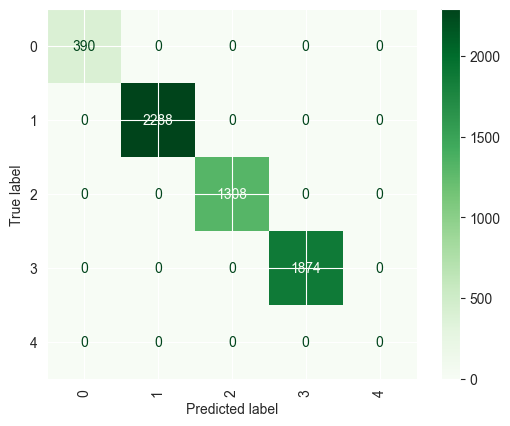

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [43]:
df_cleaned.columns

Index(['county', 'ph', 'total_n_(%)', 'toc_(%)', 'p_(ppm)', 'k_(me%)',
       'ca_(me%)', 'mg_(me%)', 'k_(ppm)', 'ca_(ppm)', 'mg_(ppm)', 'ph_score',
       'ph_class', 'ph_interpretation', 'n_score', 'n_class',
       'n_interpretation', 'oc_score', 'oc_class', 'oc_interpretation',
       'p_score', 'p_class', 'p_interpretation', 'k_score', 'k_class',
       'k_interpretation', 'ca_score', 'ca_class', 'ca_interpretation',
       'mg_score', 'mg_class', 'mg_interpretation', 'shi',
       'override_rule(s)_applied', 'final_classification',
       'recommended_actions'],
      dtype='object')

In [61]:
from sklearn.preprocessing import LabelEncoder
from notebooks_utils.auroc_evaluate import evaluate_and_plot_multiclass_roc

# 1. Re-fit the encoder on your original target column to get the names back
le = LabelEncoder()
le.fit(df_cleaned['final_classification'])

# 2. Get the class names
class_names = le.classes_ 

# Function to evaluate and plot the AUROC metrics
evaluate_and_plot_multiclass_roc(dtree, X_test, y_test, class_names, title="Soil Fertility Status Decision Tree")

Error: Model predicts 5 classes, but test set has 4 classes.


In [55]:
# Save the model to a file
joblib.dump(dtree, '../models/New_Soil_Status_decisionTree_Classifier_model.joblib')
print("Decision Tree Classifier models saved to: models/New_Soil_Status_decisionTree_Classifier_model")

Decision Tree Classifier models saved to: models/New_Soil_Status_decisionTree_Classifier_model


In [56]:
# export the decision tree model for the soil fertility status
export_model_to_json.load_model(
    model="../models/New_Soil_Status_decisionTree_Classifier_model.joblib",
    output="new_full/new-soil-fertility-status-Rules-Decision-Tree-model.json",
    visualize=True,
    viz_output="new_full/new-soil-fertility-status-Rules-Decision-Tree-model.png",  
)

Loading model from ../models/New_Soil_Status_decisionTree_Classifier_model.joblib...
Saving rules to new_full/new-soil-fertility-status-Rules-Decision-Tree-model.json...
Loading model for visualization from ../models/New_Soil_Status_decisionTree_Classifier_model.joblib...
Saving visualization to new_full/new-soil-fertility-status-Rules-Decision-Tree-model.png...
Visualization Done!
Done!


### 2. Random Forest

In [47]:
# Random forest classifier for soil fertility status prediction

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(
    class_weight='balanced_subsample', # used to change the training loss to handle class imbalance
    random_state=142
)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf.predict(X_test)

In [48]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")


Random Forest:
Accuracy: 0.9998293515358362
Precision: 0.9999
Recall: 0.9998
F1 Score: 0.9998


In [49]:
print("Classification report:\n", classification_report(y_test, y_pred_rf))

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       390
           1       1.00      1.00      1.00      2288
           2       1.00      1.00      1.00      1308
           3       1.00      1.00      1.00      1874

    accuracy                           1.00      5860
   macro avg       1.00      1.00      1.00      5860
weighted avg       1.00      1.00      1.00      5860



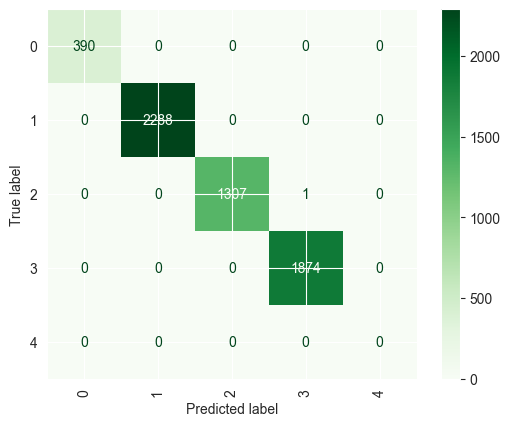

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [57]:
# Save the model to a file
joblib.dump(rf, "../models/New_Soil_Status_randomForest_Classifier_Model.joblib")
print("Random Forest Classifier saved to: models/New_Soil_Status_randomForest_Classifier")

Random Forest Classifier saved to: models/New_Soil_Status_randomForest_Classifier


In [59]:
export_model_to_json.load_model(
    model="../models/New_Soil_Status_randomForest_Classifier_Model.joblib",
    output="new_full/soil-fertility-status-Rules-Final-Random_forest-model.json",
    visualize=True,
    viz_output="new_full/soil-fertility-status-Rules-Final-Random_forest-model.png",
)

Loading model from ../models/New_Soil_Status_randomForest_Classifier_Model.joblib...
Saving rules to new_full/soil-fertility-status-Rules-Final-Random_forest-model.json...
Loading model for visualization from ../models/New_Soil_Status_randomForest_Classifier_Model.joblib...
Saving visualization to new_full/soil-fertility-status-Rules-Final-Random_forest-model.png...
Visualization Done!
Done!
